In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("C:\\Users\\ericl\\Downloads\\Lending Club Loan Dataset 2007_2011\\loan.csv")

C:\Users\ericl\AppData\Local\Temp\ipykernel_23496\2520812115.py:1: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("C:\\Users\\ericl\\Downloads\\Lending Club Loan Dataset 2007_2011\\loan.csv")


In [3]:
print(df.shape)
print(df.columns)
print(df.head())
print(df.dtypes)

(39717, 111)
Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq',
       'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens',
       'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit',
       'total_il_high_credit_limit'],
      dtype='object', length=111)
        id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  1077501    1296599       5000         5000           4975.0   36 months   
1  1077430    1314167       2500         2500           2500.0   60 months   
2  1077175    1313524       2400         2400           2400.0   36 months   
3  1076863    1277178      10000        10000          10000.0   36 months   
4  1075358    1311748       3000         3000           3000.0   60 months   

  int_rate  installment grade sub_grade  ... num_tl_90g_dpd_24m  \
0   10.65%       162.87     B    

In [4]:
df.isna().sum().sort_values(ascending=False).head(10)

df_clean=df.dropna(axis=1,thresh = len(df) * 0.5)

df_clean["annual_inc"] = df_clean["annual_inc"].fillna(df_clean["annual_inc"].median()).copy()

C:\Users\ericl\AppData\Local\Temp\ipykernel_23496\3725960610.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean["annual_inc"] = df_clean["annual_inc"].fillna(df_clean["annual_inc"].median()).copy()


In [5]:
df["loan_status"].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Current         1140
Name: count, dtype: int64

In [6]:
df_target = df_clean[df_clean["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()

df_target["loan_status"].value_counts()

loan_status
Fully Paid     32950
Charged Off     5627
Name: count, dtype: int64

68968.92637711811
59000.0
6000000.0


<Axes: >

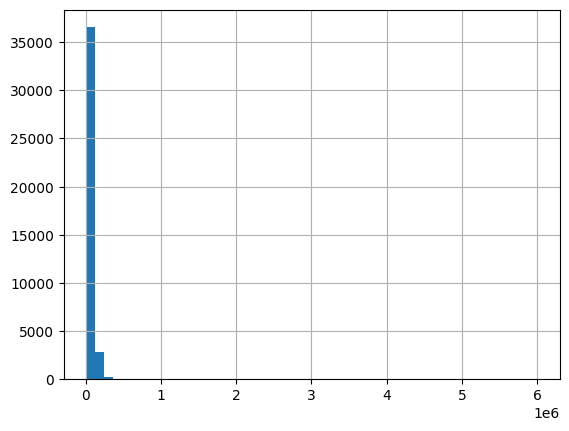

In [7]:
print(df_clean["annual_inc"].mean())
print(df_clean["annual_inc"].median())
print(df_clean["annual_inc"].max())
df_clean["annual_inc"].hist(bins=50)

In [8]:
df_target.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title',
       'emp_length', 'home_ownership', 'annual_inc', 'verification_status',
       'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose',
       'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs',
       'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec',
       'revol_bal', 'revol_util', 'total_acc', 'initial_list_status',
       'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv',
       'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code',
       'application_type', 'acc_now_delinq', 'chargeoff_within_12_mths',
       'delinq_amnt', 'pub_rec_bankruptcies', 'tax_liens'],
      dtype='object')

In [9]:
df_target.groupby("grade")["loan_amnt"].agg(["mean","median","max"])

,mean,median,max
grade,,,
A,8618.758089,7500.0,35000
B,10934.783726,10000.0,35000
C,10815.518892,9600.0,35000
D,12137.767945,10000.0,35000
E,15680.116410,15000.0,35000
F,18095.235656,18000.0,35000
G,20253.010033,20500.0,35000


In [10]:
df_target.groupby("grade")["loan_status"].value_counts(normalize=True)

grade  loan_status
A      Fully Paid     0.940070
       Charged Off    0.059930
B      Fully Paid     0.877944
       Charged Off    0.122056
C      Fully Paid     0.828057
       Charged Off    0.171943
D      Fully Paid     0.780138
       Charged Off    0.219862
E      Fully Paid     0.731506
       Charged Off    0.268494
F      Fully Paid     0.673156
       Charged Off    0.326844
G      Fully Paid     0.662207
       Charged Off    0.337793
Name: proportion, dtype: float64

In [11]:
df_target["issue_d"] = pd.to_datetime(df_target["issue_d"], format="%b-%y")

df_target["issue_year"] = df_target["issue_d"].dt.year
df_target["issue_month"] = df_target["issue_d"].dt.month

df_target.groupby("issue_year")["loan_amnt"].sum()

issue_year
2007      2219275
2008     14390275
2009     46436325
2010    122050200
2011    241065025
Name: loan_amnt, dtype: int64

In [12]:
region_map = pd.DataFrame({
    "addr_state": ["CA", "NY", "TX", "FL"],
    "region": ["West", "Northeast", "South", "South"]
})

In [13]:
df_target = df_target.merge(region_map, on = "addr_state", how= "left")

In [15]:
df_target["region"]

0         NaN
1         NaN
2         NaN
3        West
4         NaN
         ... 
38572     NaN
38573     NaN
38574     NaN
38575     NaN
38576     NaN
Name: region, Length: 38577, dtype: object

In [21]:
default_rates = df_target.groupby("purpose")["loan_status"].value_counts(normalize = True).sort_values(ascending = False).unstack()
default_rates

loan_status,Charged Off,Fully Paid
purpose,,
car,0.106738,0.893262
credit_card,0.107818,0.892182
debt_consolidation,0.153254,0.846746
educational,0.172308,0.827692
home_improvement,0.120696,0.879304
house,0.160763,0.839237
major_purchase,0.103256,0.896744
medical,0.155653,0.844347
moving,0.159722,0.840278
